In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import random
import os
from tqdm.notebook import trange

In [ ]:
# ФОРМИРОВАНИЕ ОБУЧАЮЩЕГО И ТЕСТОВЫГО ДАТАСЕТОВ

norm_k = 1 # нормировочный коэфициент

dataset_path = ('/content/drive/MyDrive/Colab Notebooks/2_dataset/')
test_dataset_path = ('/content/drive/MyDrive/Colab Notebooks/2_test_dataset/')

train_dataset_x = np.zeros ((160,12,1,64,64),dtype=float)
train_dataset_y = np.zeros ((160,12), dtype=float)

test_dataset_x = np.zeros ((40,12,1,64,64), dtype=float)
test_dataset_y = np.zeros ((40,12), dtype=float)

crit = 135/norm_k # обозначаем критерия, который определяет произошел ли фазовый переход или нет, norm_k - нормировочный коэфициент

list_f = os.listdir(dataset_path) # формирование списка папок тренировочного датасета
random.shuffle (list_f)

test_list_f = os.listdir(test_dataset_path) # формирование списка папок тестового датасета
random.shuffle (test_list_f)

# Тренировочный датасет
# в цикле произходит перебор папок (по списку) и из каждой папки загружаются набор картинок, формируя датасет
for _ in trange(len(list_f), desc="Загрузка тренировочного датасета"):
  list_file = os.listdir(dataset_path + list_f[_]) # формирование списка файлов в папке (из списка list_f)
  list_file.sort(reverse=True) # сортировка файлов по убыванию
  # print ('N:', _, list_file)

  # перебор файлов (картинок) в папке
  for i in range(len(list_file)):
    # загрузка и обработка картинок из списка list_file
    if '.png' in os.path.basename(list_file[i]):
      image = Image.open(dataset_path + list_f[_] + '/' + list_file[i])  # загрузка и обработка картинки (условие необходимо, т.к в папке есть файл .txt)
    grayscale = image.convert('L')
    np_mat = np.array(grayscale)
    train_dataset_x [_,i,0] = np_mat/norm_k # нормирование значений картинок, norm_k - нормировочный коэфициент

    mean = train_dataset_x[_,i,0].mean() # среднее значений каждой картинки

    # Для автоматической разметки (определения страйпа) нужно:
    # 1. чтобы картинка была взята из папки, в названии которой есть слово "stripe". За это отвечает условие ('stripe' in os.path.basename(list_f[_]))
    # 2. произошел фазовый переход. За это отвечает условие mean<crit
    if ('stripe' in os.path.basename(list_f[_])) and mean<crit:
      train_dataset_y[_,i] = 1

# Тестовый датасет
# в цикле произходит перебор папок (по списку) и из каждой папки загружаются набор картинок, формируя датасет
for _ in trange(len(test_list_f), desc="Загрузка тестового датасета"):
  list_file = os.listdir(test_dataset_path + test_list_f[_]) # формирование списка файлов в папке (из списка test_list_f)
  # print ('N:', _, list_file)

  # перебор файлов (картинок) в папке
  for i in range(len(list_file)):
    # загрузка и обработка картинок из списка list_file
    if '.png' in os.path.basename(list_file[i]):
      image = Image.open(test_dataset_path + test_list_f[_] + '/' + list_file[i])  # загрузка и обработка картинки (условие необходимо, т.к в папке есть файл .txt)
    grayscale = image.convert('L')
    np_mat = np.array(grayscale)
    test_dataset_x[_,i,0] = np_mat/norm_k # нормирование значений картинок, norm_k - нормировочный коэфициент

    mean = test_dataset_x[_,i,0].mean() # среднее значений каждой картинки

    # Для автоматической разметки (определения страйпа) нужно:
    # 1. чтобы картинка была взята из папки, в названии которой есть слово "stripe". За это отвечает условие ('stripe' in os.path.basename(list_f[_]))
    # 2. произошел фазовый переход. За это отвечает условие mean<crit
    if ('stripe' in os.path.basename(test_list_f[_])) and mean<crit:
      test_dataset_y[_,i] = 1


Загрузка тренировочного датасета:   0%|          | 0/160 [00:00<?, ?it/s]

KeyboardInterrupt: ignored

In [ ]:
# проверка датасета
N_folder = 65
mean_ = np.array ([])
print ('namefolder:', list_f[N_folder])

for i in range(12):
  plt.imshow(train_dataset_x[N_folder, i, 0])
  plt.show()
  mean = train_dataset_x[N_folder, i, 0].mean()
  mean_ = np.append(mean_, mean)
  print ('pic №', i, ': ', 'mean=', mean, 'class=', train_dataset_y[N_folder,i])

print (mean_)
x = np.arange(np.shape(mean_)[0])
plt.plot(x, mean_)
plt.title('mean')



Нейросеть
---


In [ ]:
# СОЗДАНИЕ НЕЙРННОЙ СЕТИ;

# создаем нейронную сеть NN
# 5 обучаемых слоев: 2 свертки и 3 полносвязных слоя

class NN(torch.nn.Module):
    def __init__(self):
        super(NN, self).__init__()

        self.conv1 = torch.nn.Conv2d(
            in_channels=1, out_channels=2, kernel_size=5, padding=2)  # ПЕРВЫЙ слой принимает 1 канал на вход (картинку 192*64), 2 - на выходе
        self.act1  = torch.nn.Tanh()  # функция активаии - гиперболический тангенс
        self.pool1 = torch.nn.MaxPool2d(kernel_size=2, stride=2) # применяет Average Pooling 2*2 (среднее значение в квадрате 2*2), ктр сжимает изображение до 96*32

        self.conv2 = torch.nn.Conv2d(
            in_channels=2, out_channels=4, kernel_size=3, padding=1) # ВТОРАЯ свёртка, 2 входных каналов (потому что на первой свертке было 2 на выходе), 4 выходных
                                                                      # padding=2, т.е. изображение остается 96*32
        self.act2  = torch.nn.Tanh()  # функция активаии
        self.pool2 = torch.nn.MaxPool2d(kernel_size=2, stride=2)   # применяет пулинг. Изображение сжимается до 48*16

        self.conv3 = torch.nn.Conv2d(
            in_channels=4, out_channels=6, kernel_size=3, padding=1) # ТРЕТЬЯ свёртка, 4 входных каналов (потому что на второй свертке было 4 на выходе), 6 выходных
                                                                      # padding=2, т.е. изображение остается 48*16
        self.act3  = torch.nn.Tanh()  # функция активаии
        self.pool3 = torch.nn.MaxPool2d(kernel_size=(3,2), stride=(3,2))   # применяет пулинг. Изображение сжимается до 16*8


        # далее растягиваем изобращение в один вектор (это делается в функции forward )
        # создаем 3 полносвязных слоя
        self.fc1   = torch.nn.Linear(16* 8 * 6, 120) # первых полносвязный слой принимает на вход изображение 16*8 глубиной 12 и на выходе получаем вектор 120
        self.act3  = torch.nn.Tanh()

        self.fc2   = torch.nn.Linear(120, 84) # второй полносвязный слой принимает на вход 120 и на выходе получаем 84
        self.act4  = torch.nn.Tanh()

        self.fc3   = torch.nn.Linear(84, 2) # третий (fully connected) слой принимает на вход 84 и на выходе получаем 2
        # self.sm   = torch.nn.Softmax(dim=1)

    # в функции forward мы приминяем все слои к тензору x (батчу)
    def forward(self, x):

        x = self.conv1(x)
        x = self.act1(x)
        x = self.pool1(x)

        x = self.conv2(x)
        x = self.act2(x)
        x = self.pool2(x)

        x = self.conv3(x)
        x = self.act3(x)
        x = self.pool3(x)

        x = x.view(x.size(0), x.size(1) * x.size(2) * x.size(3))

        x = self.fc1(x)
        x = self.act3(x)
        x = self.fc2(x)
        x = self.act4(x)
        x = self.fc3(x)
        #x = self.sm(x)

        return x

n_net = NN() # иниациализируем сеть в переменную n_net

In [ ]:
# переносим выисленея на cpu
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
n_net = n_net.to(device)

In [ ]:
# ОБЪЯВЛЕНИЕ НЕКОТОРЫХ ПАРАМЕТРОВ

power_of_pred = 2 # сила предсказания. Количество кадров, за которое нейросеть пытается предсказать образование "страйпа"

# ФОРМИРОВАНИЕ ТЕСТОВОГО НАБОРА ДАННЫХ
# формирование torch-тензора тестовой выборки. В тестовой выборке нет разделения по папкам, все элементы (триплеты) хранятся в этом тензоре

volume_test = len(test_list_f)*(np.shape (test_dataset_x)[1]-2-power_of_pred) # общее количество элементов в тестовом наборе

X_test = torch.zeros (volume_test, 1, 192, 64)
Y_test = torch.zeros (volume_test)

number_ = 0 # вспомогательный счетчик. Служит для указания индекса в torch-тензоре, куда записывается элемент тренировочного набора

for _ in trange(len(test_list_f), desc="формирование тестового набора данных"):
    for i in range (2, 12-power_of_pred):   # "-power_of_pred" из-за того, что на это значение мы предсказываем страйп, т.е рассматриваем картинки не доходя до конца,
                                            # начинаем с 2 т.к мы рассматриваем по три картинки - триплет из текущей (i) картинки из двух предыдущих (i-1 и i-2)

        # в этом цикле произходит фомирование набора данных (X_test и Y_test), на котором тестируется датасет
        # X_test состоит из трех картинок (триплетов) входящих в одну папку
        # Y_test состоит из 0 и 1. Это определяется через "power_of_pred" картинок от рассматриваемого триплета страйп или нет

        X_triplet = np.concatenate((test_dataset_x[_,i-2],test_dataset_x[_,i-1],test_dataset_x[_,i]), axis=1)
        X_test[number_] = torch.from_numpy(X_triplet)
        if test_dataset_y[_,i+power_of_pred]==1:
          Y_test[number_] = 1

        # перевод тестовых тензоров к нужному виду
        X_test = X_test.type(torch.FloatTensor)
        Y_test = Y_test.type(torch.LongTensor)

        number_ += 1

print (X_test.shape)
print (Y_test.shape)

# ФОРМИРОВАНИЕ ТРЕНИРОВОЧНОГО НАБОРА ДАННЫХ
# формирование torch-тензора тренировочной выборки. В  тренировочной выборке нет разделения по папкам, все элементы (триплеты) хранятся в этом тензоре

volume_train = len(list_f)*(np.shape (train_dataset_x)[1]-2-power_of_pred) # общее количество элементов в тестовом наборе

X_train = torch.zeros (volume_train, 1, 192, 64)
Y_train = torch.zeros (volume_train)

number_t = 0 # вспомогательный счетчик. Служит для указания индекса в torch-тензоре, куда записывается элемент тренировочного набора

for _ in trange(len(list_f), desc="формирование тренировочного набора данных"):
    for i in range (2, 12-power_of_pred):
        # в этом цикле произходит фомирование набора данных (X_test и Y_test), на котором тестируется датасет

        X_triplet = np.concatenate((train_dataset_x[_,i-2],train_dataset_x[_,i-1],train_dataset_x[_,i]), axis=1)
        X_train[number_t] = torch.from_numpy(X_triplet)
        if train_dataset_y[_,i+power_of_pred]==1:
          Y_train[number_t] = 1

        # перевод тестовых тензоров к нужному виду
        X_train = X_train.type(torch.FloatTensor)
        Y_train = Y_train.type(torch.LongTensor)

        number_t += 1


print (X_train.shape)
print (Y_train.shape)


формирование тестового набора данных:   0%|          | 0/40 [00:00<?, ?it/s]

torch.Size([320, 1, 192, 64])
torch.Size([320])


формирование тренировочного набора данных:   0%|          | 0/160 [00:00<?, ?it/s]

torch.Size([1280, 1, 192, 64])
torch.Size([1280])


In [ ]:
loss = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(n_net.parameters(), lr=0.1e-4)

In [ ]:
# ВЫБОР КОЛИЧЕСТВА ЭПОХ. это нужно чтобы создать массив для метрик TPR и FPR
number_epoch = 40

# массивы с метриками
TPR = np.zeros (number_epoch)
FPR = np.zeros (number_epoch)

def TPR_FPR (X_pred, Y, TPR, FPR, epoch): # функция для заполнения массива метрик TPR и FPR в каждую эпоху
    # обозначение: test_preds = X_pred
    # обозначение: Y_test = Y

    TP = ((X_pred.argmax(dim=1)+Y)==2).float().sum()
    pred_pos = (X_pred.argmax(dim=1)==1).float().sum() # TP+FN
    if pred_pos == 0:
      FPR[epoch] = 0
    else:
      TPR[epoch] = (TP/pred_pos).numpy()


    FP = (Y==1).float().sum()-TP
    pred_neg = (X_pred.argmax(dim=1)==0).float().sum() # FP+TN
    if pred_neg == 0:
      FPR[epoch] = 0
    else:
      FPR[epoch] = (FP/pred_neg).numpy()

    return TPR, FPR


def ROC_AUC (TPR, FPR):
    # ROC_AUC - это площадь под кривой (x = FPR, y = TPR)
    # для нахождения площади ROC_AUC используется метод прямоугольников, где площадь под кривой равна сумме площадей прямоугольников (высота которых = y_i, а ширина (x_i-x_(i-1)))
    # в нашем случае каждый прямоугольничек имеет высоту = TPR_i, а ширину = (FPR_i-FPR_(i-1))

    FPR = np.insert (FPR, 0, 0) # сдвиг нужен для того чтобы добать нулевое значение в начало массива FPR
    TPR = np.insert (TPR, 0, 0) # сдвиг нужен для того чтобы добать нулевое значение в начало массива TPR
    s_rect = np.zeros (np.shape(TPR)[0]-1) # массив хранящий площадь каждого прямоугольничка

    for i in range (np.shape(TPR)[0]-1):
        s_rect[i] = (TPR[i+1]+TPR[i])*(FPR[i+1]-FPR[i])/2

    return np.sum(s_rect)

In [ ]:
# ОБУЧЕНИЕ НЕЙРОСЕТИ
# в процессе обучения используется тренировочный набор, состоящий из триплетов (без разделения по папкам)

test_accuracy_history = []
test_loss_history = []
train_loss_history = []

batch_size = 80 # размер батча

number_of_nostripe = 0  # счетчики общего количества элементов без "страйпа"
number_of_stripe = 0    # и со "страйпом"

print (number_epoch)
for epoch in trange(number_epoch, desc="Прогресс обучения"):  # ЭПОХА. в каждую эпоху происходит проход по всем папкам из списка list
    order = np.random.permutation(len(X_train)) # рандомно перпемешанные целые числа от 0 до len(X_train)
    loss_history = torch.zeros (16)
    ind=0
    for start_index in range(0, len(X_train), batch_size): # БАТЧ. батч состоит рандомно перемешаного фрагмента тренировочного набора **(для прогресс бара): desc=f"Прогресс одной эпохи {epoch}"

        optimizer.zero_grad()

        batch_indexes = order[start_index:start_index+batch_size] # набор индексов размером с размер батча

        X_batch = X_train[batch_indexes].to(device)
        Y_batch = Y_train[batch_indexes].to(device)

        preds = n_net.forward(X_batch)

        loss_value = loss(preds, Y_batch)
        loss_history[ind]=loss_value.data  # записывает loss_value для вывода
        ind+=1

        loss_value.backward()

        optimizer.step()

        #break

    test_preds = n_net.forward(X_test)
    # print (test_preds)
    # print (Y_test)
    # print (test_preds.argmax(dim=1))

    TPR, FPR = TPR_FPR (test_preds, Y_test, TPR, FPR, epoch) # расчет  TPR и FPR

    test_loss_history.append(loss(test_preds, Y_test).data.cpu()) # записывает значение функции потерь на тестовом наборе
    train_loss_history.append(torch.mean(loss_history))           # записывает (среднее по всем батчам) значение функции потерь на тренировочном наборе

    accuracy = (test_preds.argmax(dim=1) == Y_test).float().mean().data.cpu()
    test_accuracy_history.append(accuracy)

    # if epoch%10==0:
    #   print('эпоха:', epoch)
    #   print('loss_history mean:', torch.mean(loss_history))
    #   print('loss test:', loss(test_preds, Y_test).data.cpu())
    #   print (test_preds [:10])
    #   print('accuracy:', accuracy)

    #break

roc_auc = ROC_AUC (TPR, FPR)

40


Прогресс обучения:   0%|          | 0/40 [00:00<?, ?it/s]

[0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.5        0.85714287
 0.75999999 0.74285716 0.72093022 0.75       0.72727275 0.7241379
 0.69841272 0.70833331 0.7027027  0.7027027  0.68354428 0.68354428
 0.66666669 0.66666669 0.66666669 0.66666669 0.66265059 0.65882355
 0.6511628  0.6511628  0.64367819 0.64367819]
[0.29374999 0.29374999 0.29374999 0.29374999 0.29374999 0.29374999
 0.29374999 0.29374999 0.29374999 0.29374999 0.29374999 0.29374999
 0.29374999 0.29374999 0.29374999 0.29374999 0.29245284 0.26797387
 0.25423729 0.23859648 0.22743683 0.20522387 0.20377359 0.19847329
 0.19455253 0.1733871  0.17073171 0.17073171 0.16597511 0.16597511
 0.16736402 0.16736402 0.16736402 0.16736402 0.16455697 0.16170213
 0.16239317 0.16239317 0.16309012 0.16309012]
-0.09397398248362965


Text(0, 0.5, 'TPR')

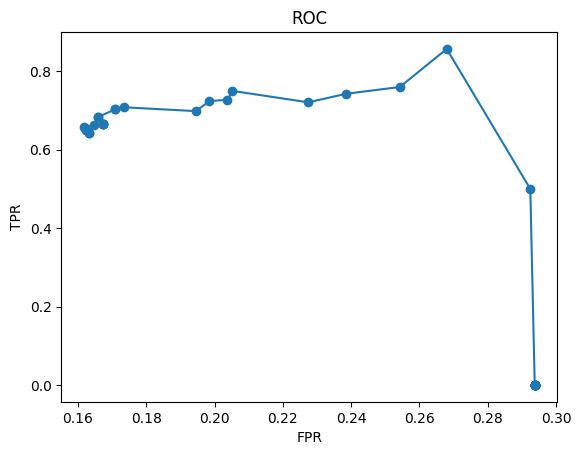

In [ ]:
print (TPR)
print (FPR)
print (roc_auc)

plt.plot(FPR, TPR, 'o-')
plt.title('ROC')
plt.xlabel('FPR')
plt.ylabel('TPR')

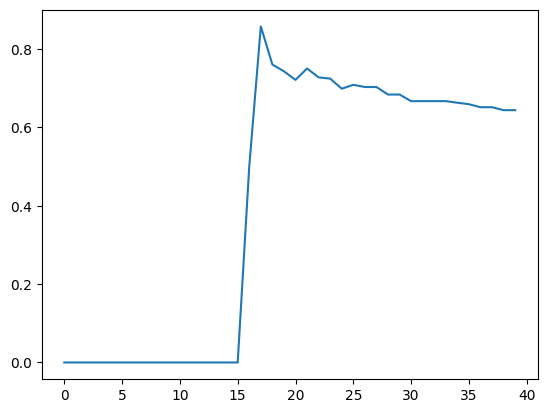

In [ ]:
plt.plot(TPR)

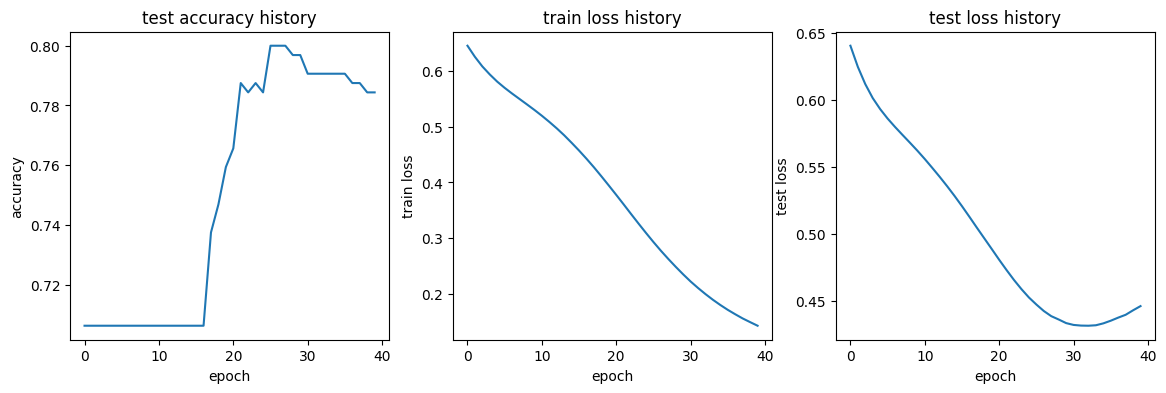

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(
    nrows=1, ncols=3,
    figsize=(14, 4)
)

ax1.plot(test_accuracy_history)
ax1.set_title('test accuracy history')
ax1.set_xlabel('epoch')
ax1.set_ylabel('accuracy')

ax2.plot(train_loss_history)
ax2.set_title('train loss history')
ax2.set_xlabel('epoch')
ax2.set_ylabel('train loss')

ax3.plot(test_loss_history)
ax3.set_title('test loss history')
ax3.set_xlabel('epoch')
ax3.set_ylabel('test loss')


plt.show()


# plt.plot(test_accuracy_history);
# plt.plot(test_loss_history);
# plt.plot(train_loss_history);

In [ ]:
for p in n_net.parameters():
  print(p)
  # print (p.grad.shape)

Parameter containing:
tensor([[[[ 0.0947, -0.0597,  0.0118,  0.0302,  0.0477],
          [ 0.0968,  0.1957,  0.1388,  0.1182, -0.1132],
          [-0.1790,  0.0531, -0.0368, -0.0152,  0.0884],
          [ 0.0799, -0.0059, -0.0978,  0.0191,  0.0854],
          [-0.1281, -0.0634, -0.1850, -0.1728,  0.0278]]],


        [[[-0.0307, -0.1088, -0.1592,  0.0109,  0.1370],
          [-0.1282,  0.1267, -0.0376, -0.0767, -0.0430],
          [ 0.1679, -0.0414, -0.1125, -0.0559, -0.1774],
          [ 0.1131, -0.0408,  0.1718, -0.0747,  0.0899],
          [-0.1157, -0.0951, -0.0402,  0.1796, -0.0164]]]], requires_grad=True)
Parameter containing:
tensor([-0.1106, -0.0901], requires_grad=True)
Parameter containing:
tensor([[[[-0.0709, -0.0418, -0.2030],
          [ 0.2324, -0.2223, -0.1354],
          [ 0.1288,  0.0831, -0.1328]],

         [[-0.2046,  0.1820,  0.1841],
          [ 0.2257, -0.1549, -0.1496],
          [-0.1977,  0.0907,  0.1556]]],


        [[[-0.0497,  0.0684, -0.1966],
          [

In [ ]:
print ('sum', number_of_stripe+number_of_nostripe) #, 'number_of_stripe:', number_of_stripe, 'number_of_nostripe', number_of_nostripe)
print (percent_stripe)
print (percent_nostripe)

sum 633544
0.28359375
0.71640625


Пробники
---

In [ ]:
print (Y_test)
print (test_preds)

TP = ((test_preds.argmax(dim=1)+Y_test)==2).float().sum().data.cpu()
pred_pos = (test_preds.argmax(dim=1)==1).float().sum().data.cpu() # TP+FN
TPR = (TP/pred_pos)

FP = (Y_test==1).float().sum()-TP
pred_neg = (test_preds.argmax(dim=1)==0).float().sum().data.cpu() # FP+TN
FPR = FP/pred_neg

print (TP)
print (pred_pos)
print (TPR)

print (FP)
print (pred_neg)
print (FPR)


In [ ]:
# ОБУЧЕНИЕ НЕЙРОСЕТИ
# в процессе обучения в батчах используются данные только одной папки

test_accuracy_history = []
test_loss_history = []

number_of_nostripe = 0  # счетчики общего количества элементов без "страйпа"
number_of_stripe = 0    # и со "страйпом"

for epoch in trange(5000, desc="Прогресс обучения"):  # ЭПОХА. в каждую эпоху происходит проход по всем папкам из списка list

    for _ in range(len(list_f)): # БАТЧ. батч состоит из картинок одной папки **(для прогресс бара): desc=f"Прогресс одной эпохи {epoch}"
        optimizer.zero_grad()

        X_train=torch.zeros (np.shape (train_dataset_x)[1]-2-power_of_pred, 1, 192, 64)
        Y_train=torch.zeros (np.shape (train_dataset_x)[1]-2-power_of_pred)

        for i in range (2, 12-power_of_pred):  # "-power_of_pred" из-за того, что на это значение мы предсказываем страйп, т.е рассматриваем картинки не доходя до конца,
                                               # начинаем с 2 т.к мы рассматриваем по три картинки - триплет из текущей (i) картинки из двух предыдущих (i-1 и i-2)
            # в этом цикле произходит фрмирование батча - X_train, Y_train, на которых обучается нейросеть; аналогично фомированию тестового набора данных

            X_triplet = np.concatenate((train_dataset_x[_,i-2],train_dataset_x[_,i-1],train_dataset_x[_,i]), axis=1)

            X_train[i-2] = torch.from_numpy(X_triplet)
            if train_dataset_y[_,i+power_of_pred]==1:
              Y_train[i-2] = 1

            # перевод тренировочных тензоров к нужному виду
            X_train = X_train.type(torch.FloatTensor)
            Y_train = Y_train.type(torch.LongTensor)

            # подсчет общего количества элементов со страйпом и без
            if epoch<1:
              if train_dataset_y[_,i+power_of_pred]==1:
                number_of_stripe+= 1
              else:
                number_of_nostripe+= 1

        preds = n_net.forward(X_train)

        loss_value = loss(preds, Y_train)
        #print (loss_value)

        loss_value.backward()
        #print (loss_value)

        optimizer.step()

        #break

    test_preds = n_net.forward(X_test)
    # print (test_preds)
    # print (Y_test)
    # print (test_preds.argmax(dim=1))

    test_loss_history.append(loss(test_preds, Y_test).data.cpu())

    accuracy = (test_preds.argmax(dim=1) == Y_test).float().mean().data.cpu()
    test_accuracy_history.append(accuracy)

    if epoch%50==0:
       print(epoch, accuracy)

    #break

percent_stripe = number_of_stripe/(number_of_stripe+number_of_nostripe)
percent_nostripe = number_of_nostripe/(number_of_stripe+number_of_nostripe)

In [ ]:
# такие функии как random.seed( "число" ) позволяют зафиксировать определенную случайную последовательность
# которая будет всегда одинаковая при любом вызове этой функции с определенным аргументом "число"

random.seed(0)
np.random.seed(0)
torch.manual_seed(0)
torch.cuda.manual_seed(0)
torch.backends.cudnn.deterministic = True

In [ ]:
# перевод массивов с датасетом в torch-тензор

torch_train_X = torch.from_numpy (train_X)
torch_train_Y = torch.from_numpy (train_Y)

torch_test_X = torch.from_numpy (test_X)
torch_test_Y = torch.from_numpy (test_Y)

torch_train_X = torch_train_X.type(torch.FloatTensor)
torch_test_X = torch_test_X.type(torch.FloatTensor)
# print (torch_train_X.type())

torch_train_Y = torch_train_Y.type(torch.LongTensor)
torch_test_Y = torch_test_Y.type(torch.LongTensor)

In [ ]:
# изображения и преобразование его в матрицу

image = Image.open('/content/T=0.1146.png') # импорт изображения
grayscale = image.convert('L')  # преобразование его в моноканальное (черно-белое) изображение
m=np.array(grayscale) # преобразование изображения в матрицу Numpy
print (m)

# визуализация получившейся матрицы
plt.imshow(m)
plt.show()

In [ ]:
class LeNet5(torch.nn.Module):
    def __init__(self):
        super(LeNet5, self).__init__()

        self.conv1 = torch.nn.Conv2d(
            in_channels=1, out_channels=6, kernel_size=5, padding=2)  # первый слой принимает 1 канал на вход, 6 - на выходе
        self.act1  = torch.nn.Tanh()  # функция активаии - гиперболический тангенс
        self.pool1 = torch.nn.AvgPool2d(kernel_size=2, stride=2) # применяет Average Pooling 2*2 (среднее значение в квадрате 2*2), ктр сжимает изображение до 32*32

        self.conv2 = torch.nn.Conv2d(
            in_channels=6, out_channels=16, kernel_size=5, padding=2) # вторая свёртка, 6 входных каналов (потому что на первой свертке было 6 на выходе), 16 выходных
                                                                      # padding=0, т.е. свёртка обрежет изображение до 32*32
        self.act2  = torch.nn.Tanh()  # функция активаии
        self.pool2 = torch.nn.AvgPool2d(kernel_size=2, stride=2)   # применяет пулинг. Изображение сжимается до 16*16

        # далее растягиваем изобращение в один вектор (это делается в функции forward )
        # создаем 3 полносвязных слоя
        self.fc1   = torch.nn.Linear(5 * 5 * 16, 120) # первых полносвязный слой принимает на вход изображение 5*5 глубиной 16 и на выходе получаем вектор 120
        self.act3  = torch.nn.Tanh()

        self.fc2   = torch.nn.Linear(120, 84) # второй полносвязный слой принимает на вход 120 и на выходе получаем 84
        self.act4  = torch.nn.Tanh()

        self.fc3   = torch.nn.Linear(84, 10) # третий (fully connected) слой принимает на вход 84 и на выходе получаем 10

    # в функции forward мы приминяем все слои к тензору x (батчу)
    def forward(self, x):

        x = self.conv1(x)
        x = self.act1(x)
        x = self.pool1(x)

        x = self.conv2(x)
        x = self.act2(x)
        x = self.pool2(x)

        x = x.view(x.size(0), x.size(1) * x.size(2) * x.size(3))

        x = self.fc1(x)
        x = self.act3(x)
        x = self.fc2(x)
        x = self.act4(x)
        x = self.fc3(x)

        return x

lenet5 = LeNet5() # иниациализируем сеть в переменную lenet5

In [ ]:
loss = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(lenet5.parameters(), lr=1.0e-3)

In [ ]:
test_accuracy_history = []
test_loss_history = []

for epoch in range(10000):
    order = np.random.permutation(len(X_train))
    for start_index in range(0, len(X_train), batch_size):
        optimizer.zero_grad()

        batch_indexes = order[start_index:start_index+batch_size]

        X_batch = X_train[batch_indexes].to(device)
        y_batch = y_train[batch_indexes].to(device)

        preds = lenet5.forward(X_batch)

        loss_value = loss(preds, y_batch)
        loss_value.backward()

        optimizer.step()

    test_preds = lenet5.forward(X_test)
    test_loss_history.append(loss(test_preds, y_test).data.cpu())

    accuracy = (test_preds.argmax(dim=1) == y_test).float().mean().data.cpu()
    test_accuracy_history.append(accuracy)

    print(accuracy)

In [ ]:
# формирование датасета
# формирование списка папок, из который будет формироватся датасет

list_f = os.listdir('/content/drive/MyDrive/Colab Notebooks/dataset/') # формирование списка папок
random.shuffle (list_f)
# print (list_f[2:20])

# в цикле произходит перебор папок (по списку) и из каждой папки загружаются набор картинок, формируя датасет
for _ in range(len(list_f)):
  list_file = os.listdir('/content/drive/MyDrive/Colab Notebooks/dataset/'+list_f[_]) # формирование списка файлов в папке (из списка list_f)
  X_train = torch.zeros ((len(list_file),64,64))
  Y_train = torch.zeros (len(list_file))

  for i in range(len(list_file)):
    # загрузка и обработка картинок из списка list_file
    if '*.png' in os.path.basename(list_file[i]):
      image = Image.open('/content/drive/MyDrive/Colab Notebooks/dataset/'+list_f[_]+'/'+list_file[i])  # загрузка и обработка картинки (условие необходимо, т.к в папке есть файл .txt)
    grayscale = image.convert('L')
    m=np.array(grayscale)
    X_train[i] = torch.from_numpy (m)
    if ('nostripe' in os.path.basename(list_f[_])): # проверка есть ли в названии папки слово "nostripe". В этих папках содержится картинка без "страйпа"
      Y_train[i] = 1 # хрень!




print (X_train)
print (Y_train)

NameError: ignored

In [ ]:
# проверка возможности поиска ключевого слова в названии папки

list_f = os.listdir('/content/drive/MyDrive/Colab Notebooks/dataset/') # формирование списка папок
t=0 # номер в списке используемой папки

# цикл, который неработает т.к как хотелось бы
for _ in range (len(list_f)):
  if list_f[_]=="nostripe **":
    print (_)
  # else:
  #   print ('none')
  #   t+=1
  #   print (t)

print (os.path.basename(list_f[105]))
'nostripe' in os.path.basename(list_f[5]) # возвращает True если 'nostripe' есть в папке list_f[5]

nostripe 2023-03-28T22_35_50


False

In [ ]:
# эксперемент с функцией continue

test = np.zeros ((10,10))
for i in range (10):
    test [i] = np.arange(10)

print (test)

a=[]

for i in range (10):
    for t in range (10):
        if test [i,t]>5:
            continue
        a.append (test[i,t])

print (a)

[[0. 1. 2. 3. 4. 5. 6. 7. 8. 9.]
 [0. 1. 2. 3. 4. 5. 6. 7. 8. 9.]
 [0. 1. 2. 3. 4. 5. 6. 7. 8. 9.]
 [0. 1. 2. 3. 4. 5. 6. 7. 8. 9.]
 [0. 1. 2. 3. 4. 5. 6. 7. 8. 9.]
 [0. 1. 2. 3. 4. 5. 6. 7. 8. 9.]
 [0. 1. 2. 3. 4. 5. 6. 7. 8. 9.]
 [0. 1. 2. 3. 4. 5. 6. 7. 8. 9.]
 [0. 1. 2. 3. 4. 5. 6. 7. 8. 9.]
 [0. 1. 2. 3. 4. 5. 6. 7. 8. 9.]]
[0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 0.0, 1.0, 2.0, 3.0, 4.0, 5.0]


Folder N: 46 name folder: 2023-03-27T16_49_12
81
['T=0.4900.png', 'T=0.4706.png', 'T=0.4612.png', 'T=0.4430.png', 'T=0.4254.png', 'T=0.4169.png', 'T=0.4004.png', 'T=0.3846.png', 'T=0.3769.png', 'T=0.3620.png', 'T=0.3477.png', 'T=0.3339.png', 'T=0.3272.png', 'T=0.3143.png', 'T=0.3018.png', 'T=0.2958.png', 'T=0.2841.png', 'T=0.2728.png', 'T=0.2620.png', 'T=0.2568.png', 'T=0.2467.png', 'T=0.2370.png', 'T=0.2323.png', 'T=0.2231.png', 'T=0.2142.png', 'T=0.2057.png', 'T=0.2016.png', 'T=0.1936.png', 'T=0.1859.png', 'T=0.1786.png', 'T=0.1750.png', 'T=0.1681.png', 'T=0.1614.png', 'T=0.1550.png', 'T=0.1519.png', 'T=0.1459.png', 'T=0.1401.png', 'T=0.1346.png', 'T=0.1319.png', 'T=0.1267.png', 'T=0.1217.png', 'T=0.1169.png', 'T=0.1146.png', 'T=0.1101.png', 'T=0.1057.png', 'T=0.1036.png', 'T=0.0995.png', 'T=0.0956.png', 'T=0.0937.png', 'T=0.0900.png', 'T=0.0864.png', 'T=0.0830.png', 'T=0.0813.png', 'T=0.0781.png', 'T=0.0750.png', 'T=0.0720.png', 'T=0.0706.png', 'T=0.0678.png', 'T=0.0651.png', 'T=0.0

Text(0.5, 1.0, 'mean')

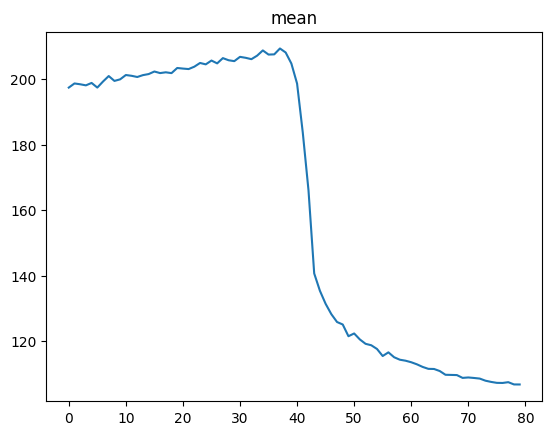

In [ ]:
# ЗАДАЧА КРИТЕРИЯ

# здесь я загружаю картинки одного моделирования, в котором есть страйп
# затем нахожу параметры для автоматического определения страйпа

# Алгоритм работает следующим образом:
# 1. каждой картинке ставится в соответсвие число, равное среднему значению всех элементов матрицы этой картинки
# 2. подбирается пороговое значение, которое позволяет отделить "страйпы" от "нестрайпов"

list_f = os.listdir(dataset_path) # формирование списка папок
N_folder = 46 # номер используемой папки
print ('Folder N:', N_folder, 'name folder:', list_f[N_folder])

list_file = os.listdir(dataset_path+list_f[N_folder]) # формирование списка файлов в папке под номером N_folder (из списка list_f)
print (len(list_file))
list_file.sort(reverse=True) # сортировка файлов по убыванию
list_file.pop(0) # удаление первого элемента 'co.txt'. он не нужен
print (list_file)

pic_mat = np.zeros ((len(list_file),64,64)) # создание нулевой матрицы для хранение (len(list_file) картинок 64*64
clas = np.zeros (len(list_file)) # создание нулевой матрицы для хранение меток (класса) каждой картинки

sum = np.array ([]) # (НЕ ИСПОЛЬЗУЕТСЯ) в этой матрице будем хранить поэлементную сумму значений каждой картинки
mean = np.array ([]) # в этой матрице будем хранить среднее значений каждой картинки

for i in range(len(list_file)):
  # загрузка и обработка картинок из списка list_file
  if '.png' in os.path.basename(list_file[i]):
    image = Image.open(dataset_path+list_f[N_folder]+'/'+list_file[i])  # загрузка и обработка картинки (условие необходимо, т.к в папке есть файл .txt)
    grayscale = image.convert('L')
    pic_mat[i]=np.array(grayscale)

  # sum = np.append(sum,pic_mat[i-t].sum())
  mean = np.append(mean,pic_mat[i].mean())

print ('len list_file:', len(list_file))
print ('shape pic_mat:', np.shape(pic_mat))

x=np.arange(np.shape(mean)[0])
plt.plot(x, mean)
plt.title('mean')


i: 0  clas: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1.]
i: 1  clas: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1.]
i: 2  clas: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1.]
i: 3  clas: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1

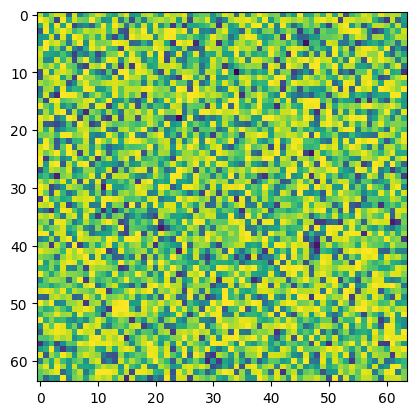

mean 0 :  197.44921875
clas 0 :  0.0


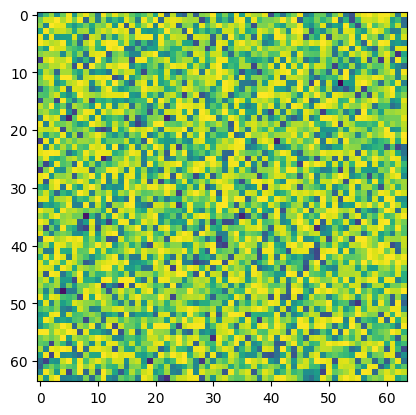

mean 1 :  198.7109375
clas 1 :  0.0


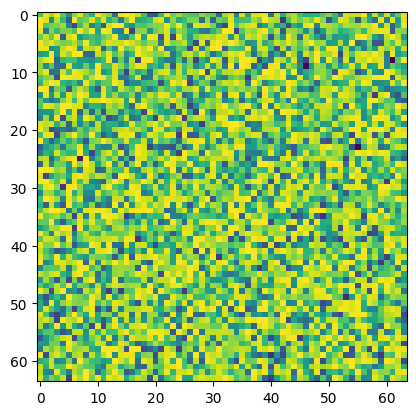

mean 2 :  198.4619140625
clas 2 :  0.0


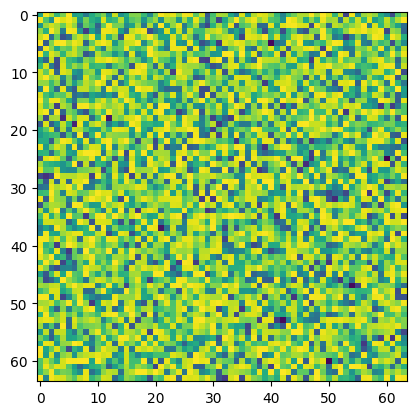

mean 3 :  198.13427734375
clas 3 :  0.0


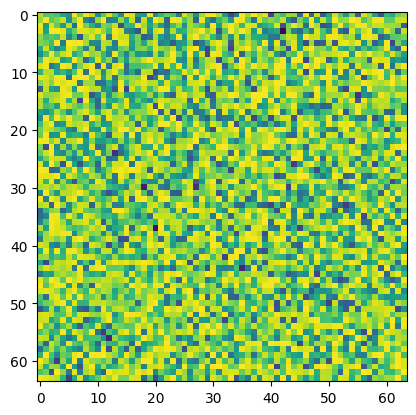

mean 4 :  198.868408203125
clas 4 :  0.0


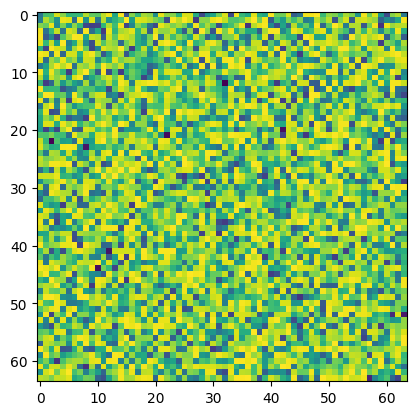

mean 5 :  197.456787109375
clas 5 :  0.0


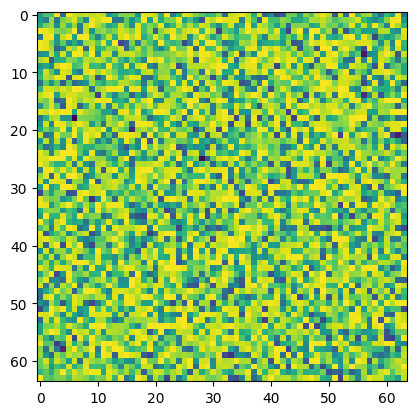

mean 6 :  199.300048828125
clas 6 :  0.0


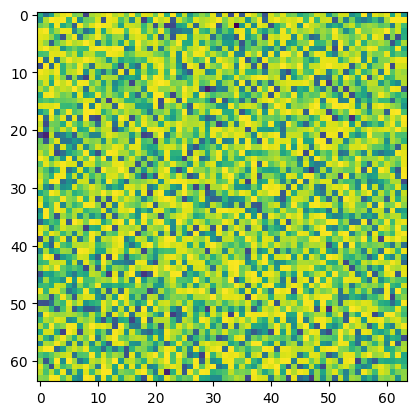

mean 7 :  200.97314453125
clas 7 :  0.0


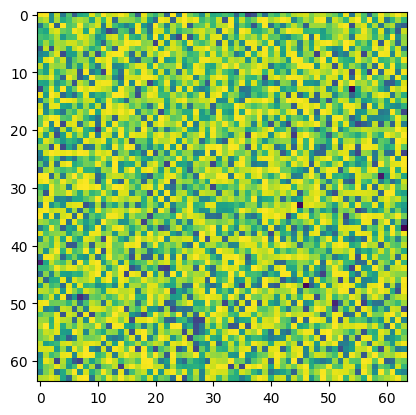

mean 8 :  199.489013671875
clas 8 :  0.0


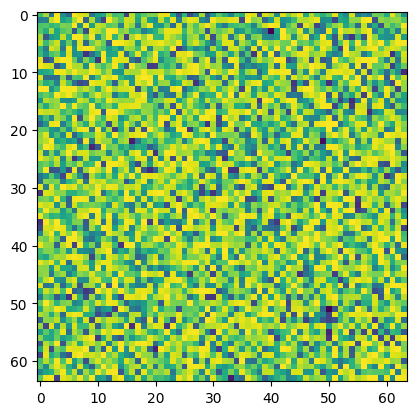

mean 9 :  199.965576171875
clas 9 :  0.0


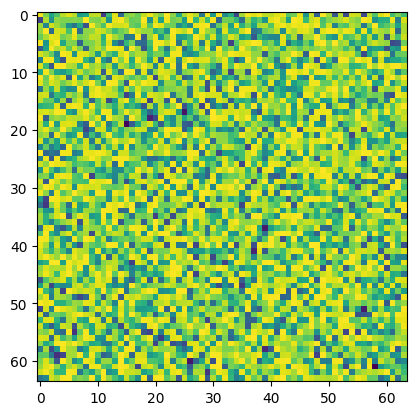

mean 10 :  201.2861328125
clas 10 :  0.0


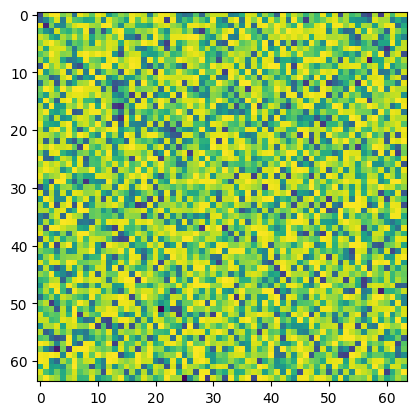

mean 11 :  201.05078125
clas 11 :  0.0


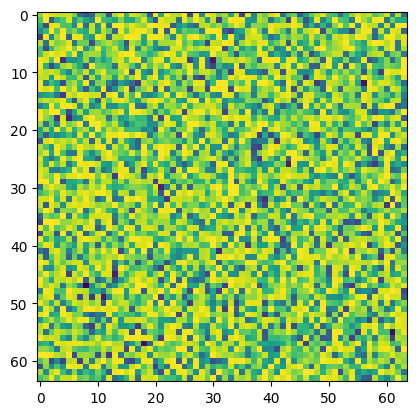

mean 12 :  200.6865234375
clas 12 :  0.0


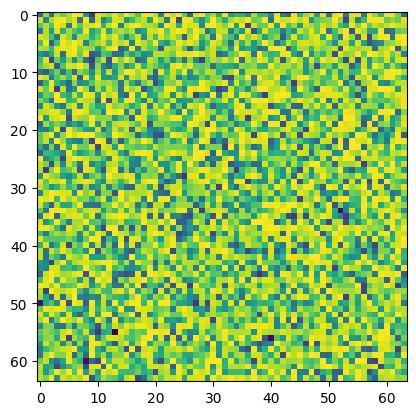

mean 13 :  201.25634765625
clas 13 :  0.0


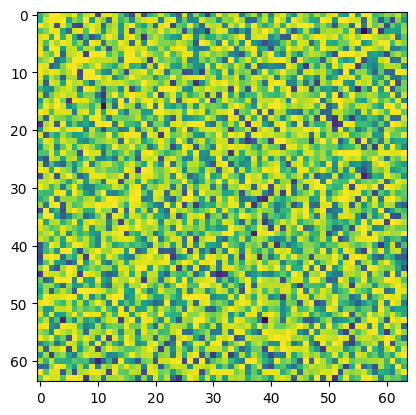

mean 14 :  201.58056640625
clas 14 :  0.0


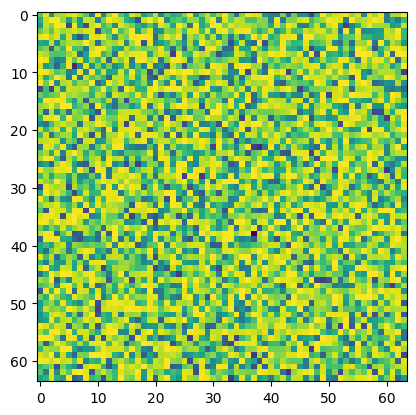

mean 15 :  202.36083984375
clas 15 :  0.0


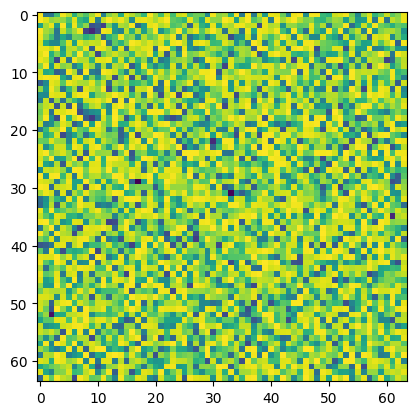

mean 16 :  201.878662109375
clas 16 :  0.0


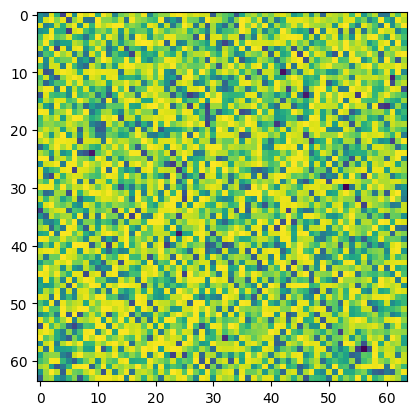

mean 17 :  202.12060546875
clas 17 :  0.0


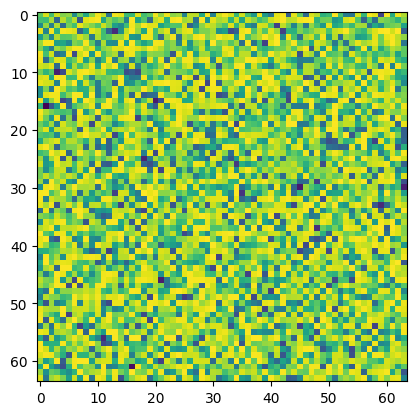

mean 18 :  201.864990234375
clas 18 :  0.0


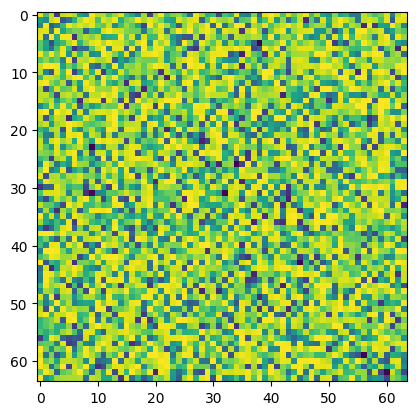

mean 19 :  203.436767578125
clas 19 :  0.0


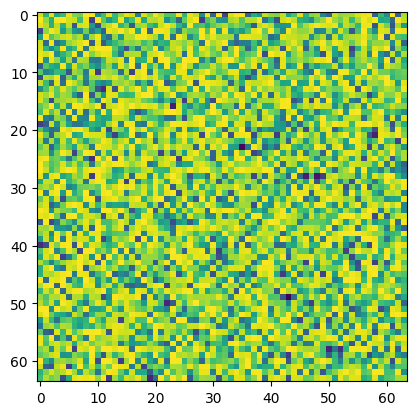

mean 20 :  203.25537109375
clas 20 :  0.0


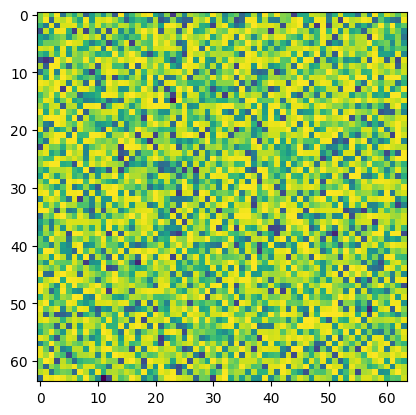

mean 21 :  203.10693359375
clas 21 :  0.0


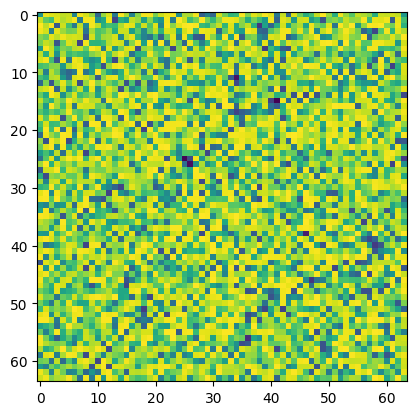

mean 22 :  203.835205078125
clas 22 :  0.0


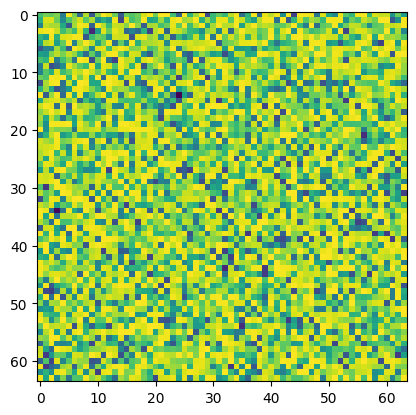

mean 23 :  204.971435546875
clas 23 :  0.0


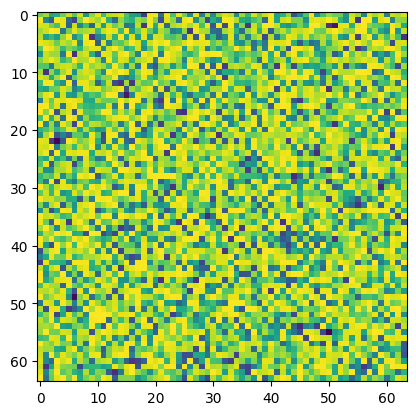

mean 24 :  204.542724609375
clas 24 :  0.0


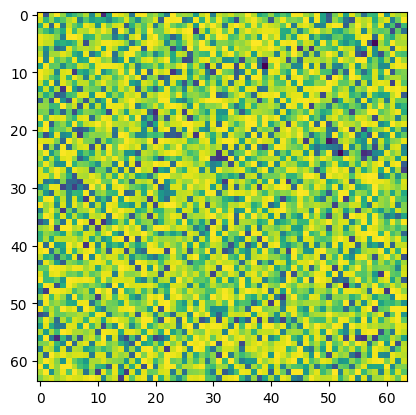

mean 25 :  205.709228515625
clas 25 :  0.0


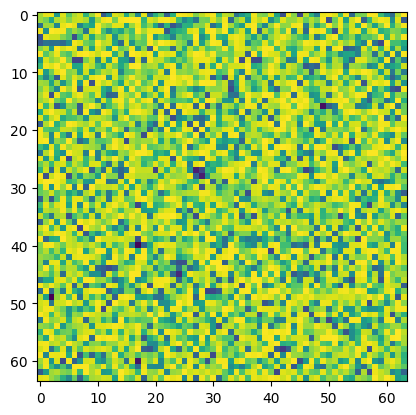

mean 26 :  204.84521484375
clas 26 :  0.0


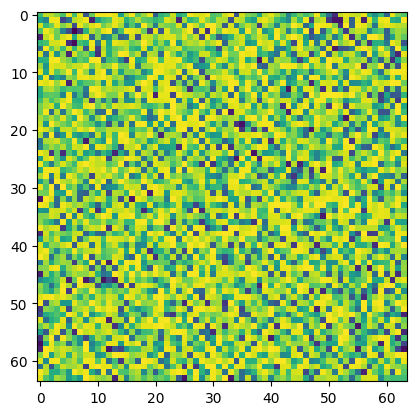

mean 27 :  206.450439453125
clas 27 :  0.0


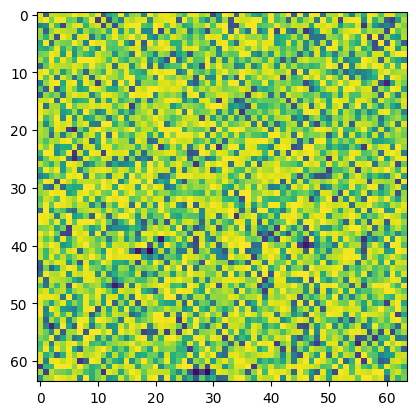

mean 28 :  205.801025390625
clas 28 :  0.0


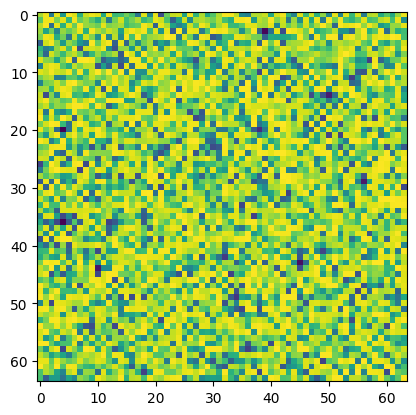

mean 29 :  205.525390625
clas 29 :  0.0


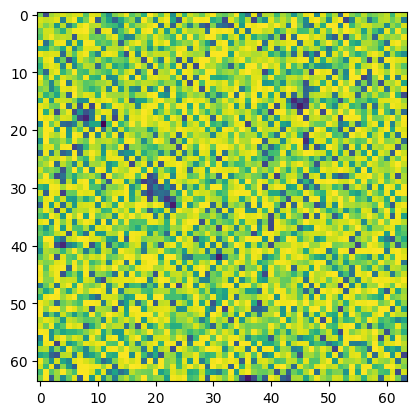

mean 30 :  206.83837890625
clas 30 :  0.0


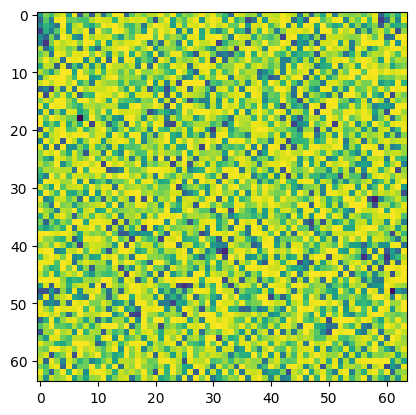

mean 31 :  206.54248046875
clas 31 :  0.0


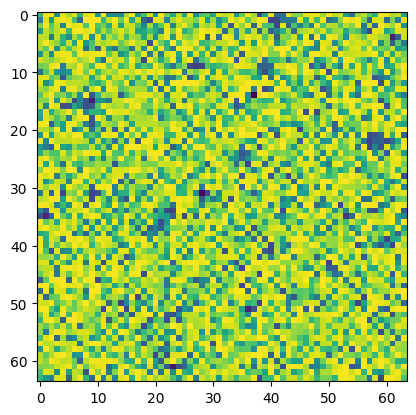

mean 32 :  206.12939453125
clas 32 :  0.0


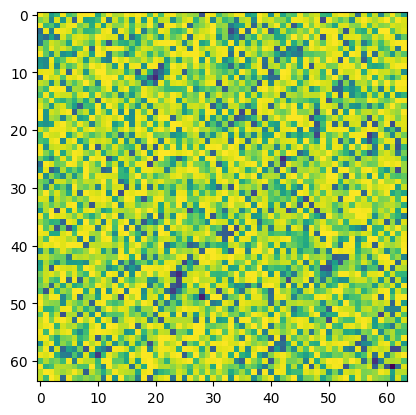

mean 33 :  207.20068359375
clas 33 :  0.0


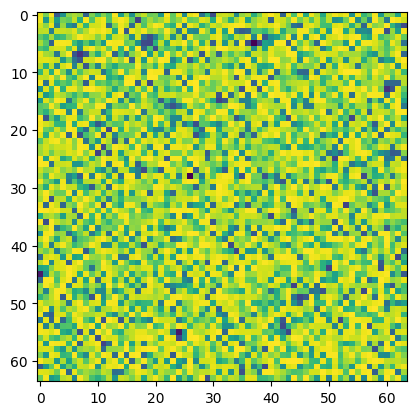

mean 34 :  208.799560546875
clas 34 :  0.0


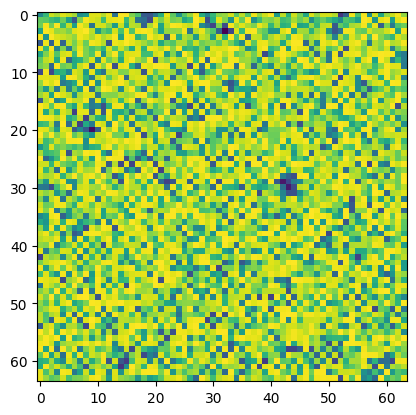

mean 35 :  207.53271484375
clas 35 :  0.0


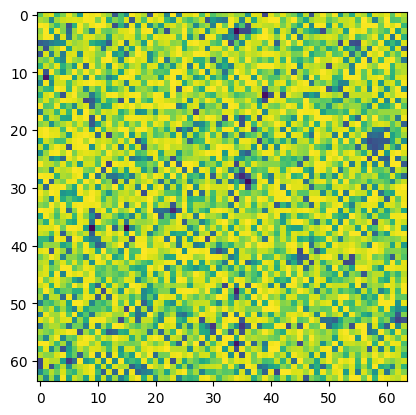

mean 36 :  207.597900390625
clas 36 :  0.0


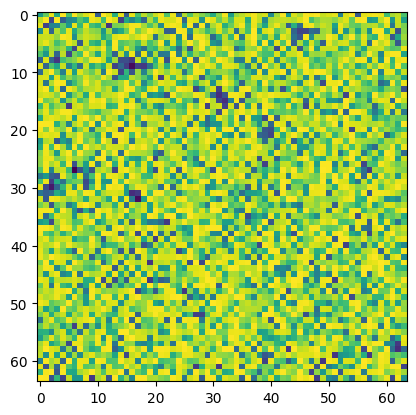

mean 37 :  209.39501953125
clas 37 :  0.0


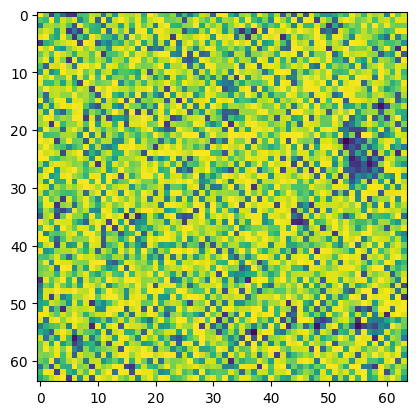

mean 38 :  208.17041015625
clas 38 :  0.0


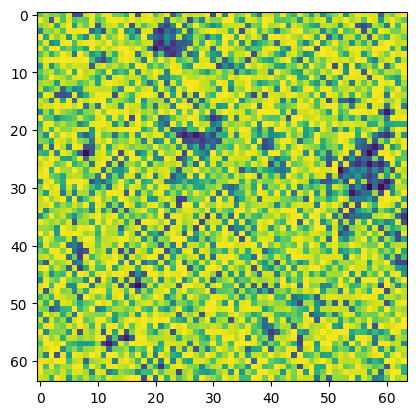

mean 39 :  204.798828125
clas 39 :  0.0


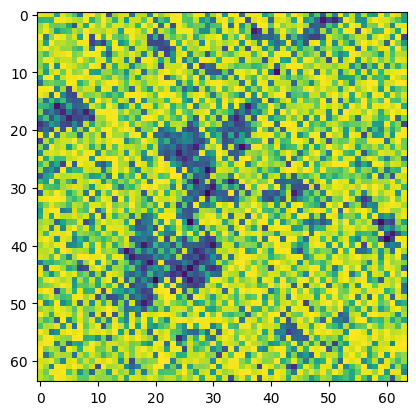

mean 40 :  198.6728515625
clas 40 :  0.0


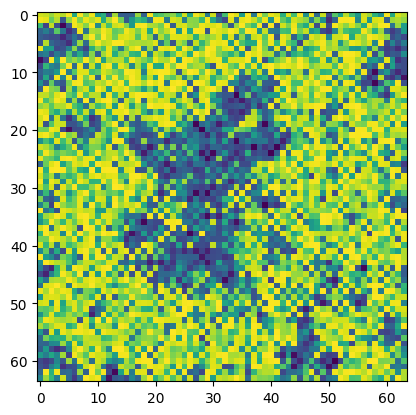

mean 41 :  183.7001953125
clas 41 :  0.0


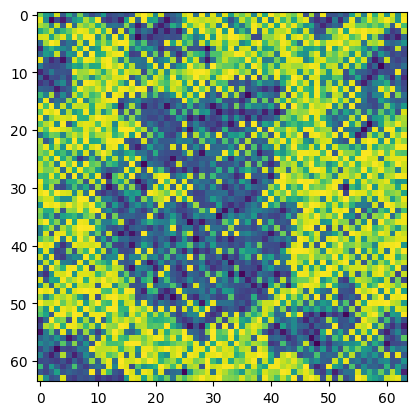

mean 42 :  166.0810546875
clas 42 :  0.0


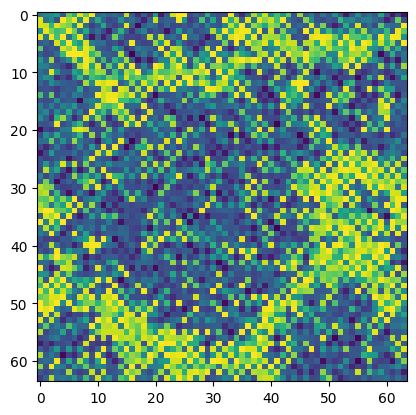

mean 43 :  140.688232421875
clas 43 :  0.0


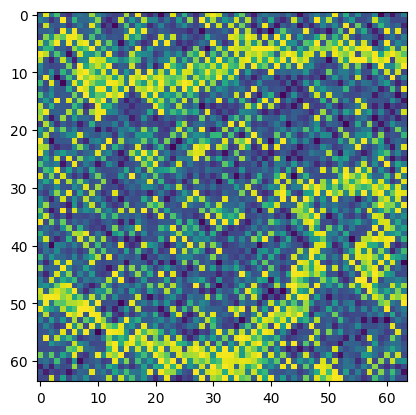

mean 44 :  135.388427734375
clas 44 :  1.0


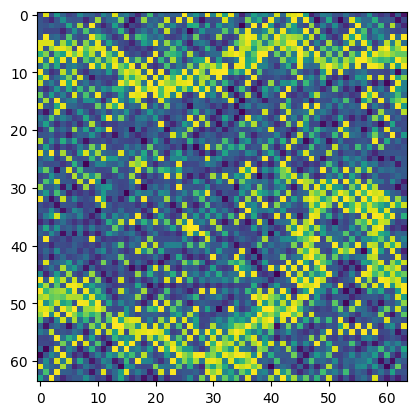

mean 45 :  131.4091796875
clas 45 :  1.0


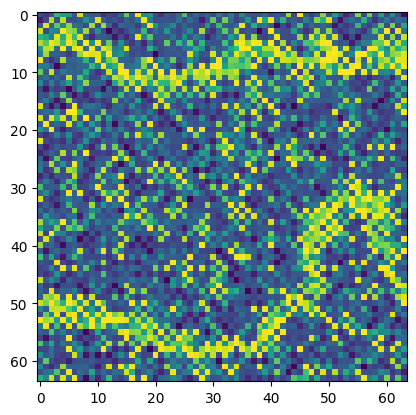

mean 46 :  128.2509765625
clas 46 :  1.0


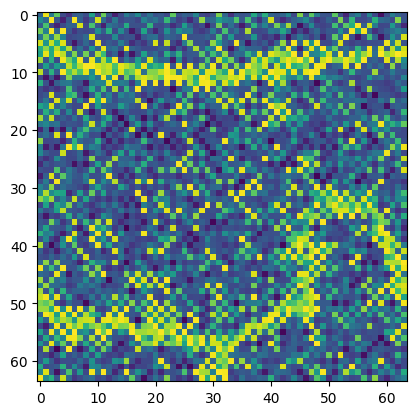

mean 47 :  125.848388671875
clas 47 :  1.0


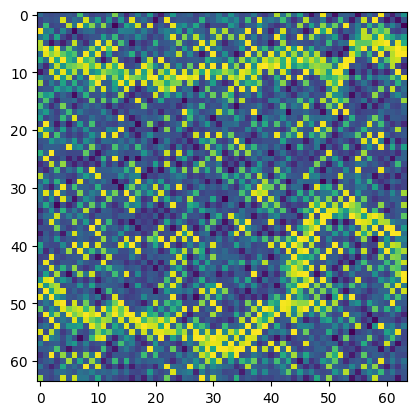

mean 48 :  125.08984375
clas 48 :  1.0


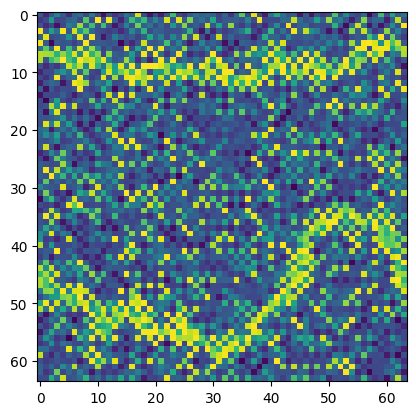

mean 49 :  121.51025390625
clas 49 :  1.0


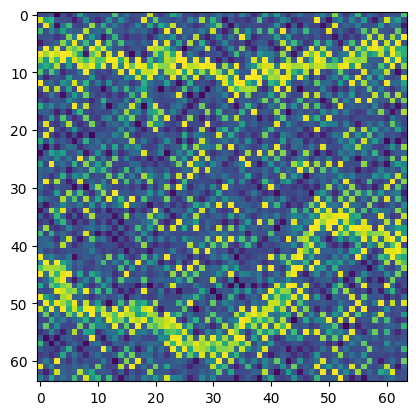

mean 50 :  122.35009765625
clas 50 :  1.0


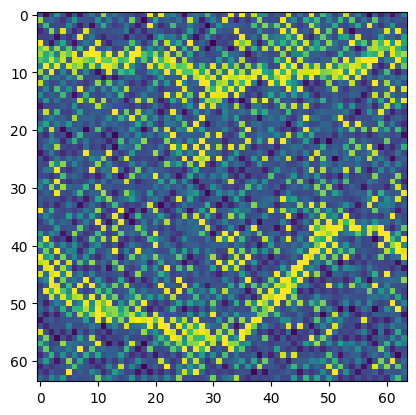

mean 51 :  120.522216796875
clas 51 :  1.0


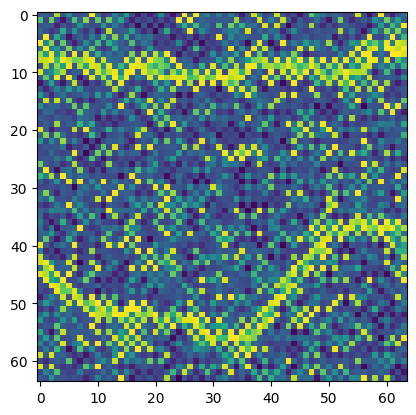

mean 52 :  119.18798828125
clas 52 :  1.0


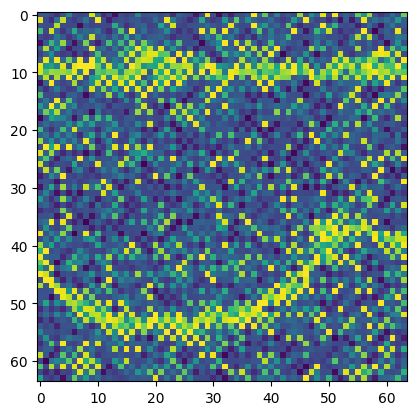

mean 53 :  118.745849609375
clas 53 :  1.0


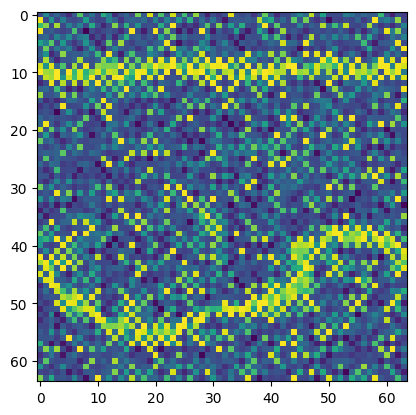

mean 54 :  117.6171875
clas 54 :  1.0


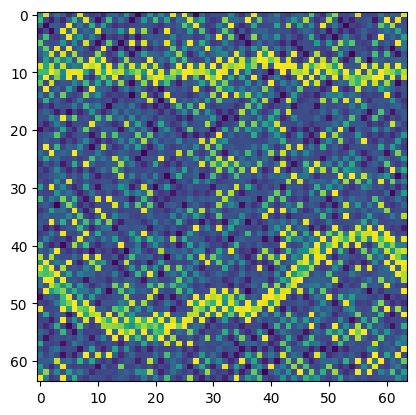

mean 55 :  115.460693359375
clas 55 :  1.0


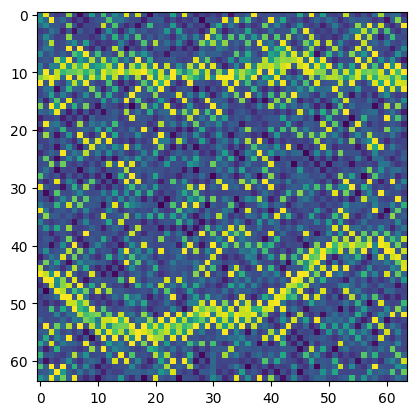

mean 56 :  116.581298828125
clas 56 :  1.0


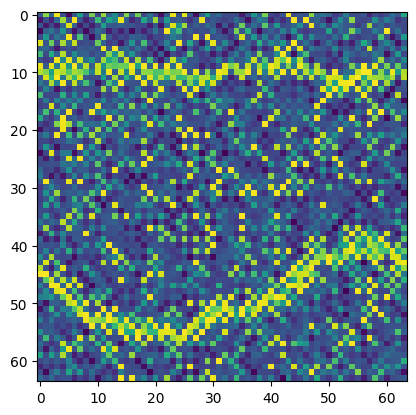

mean 57 :  115.091552734375
clas 57 :  1.0


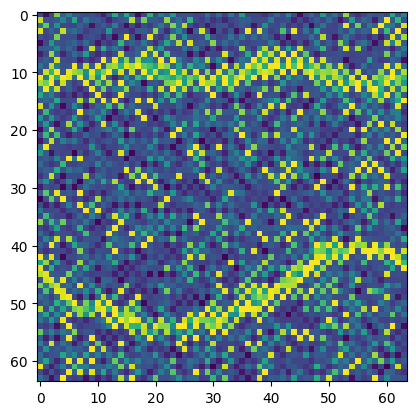

mean 58 :  114.335205078125
clas 58 :  1.0


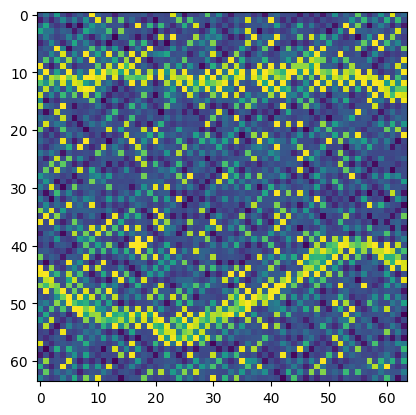

mean 59 :  114.0322265625
clas 59 :  1.0


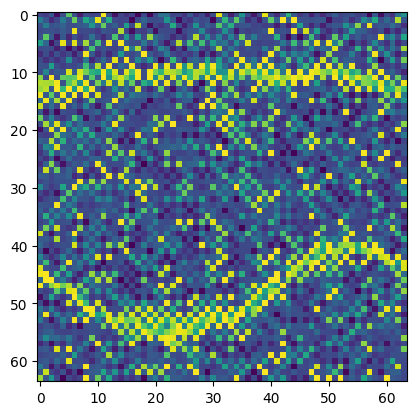

mean 60 :  113.5595703125
clas 60 :  1.0


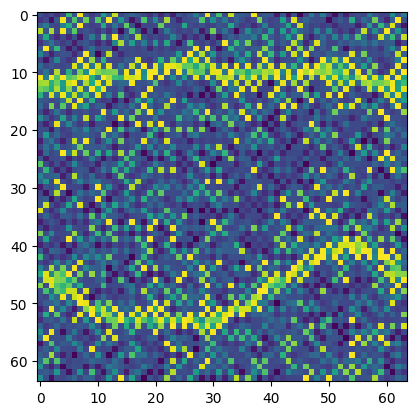

mean 61 :  112.921630859375
clas 61 :  1.0


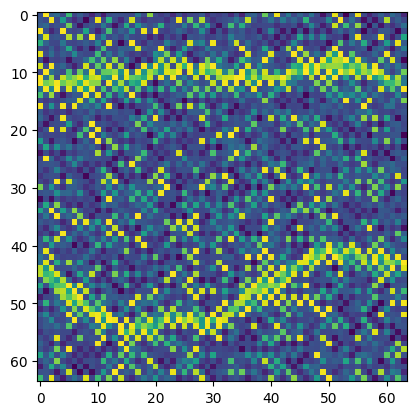

mean 62 :  112.13134765625
clas 62 :  1.0


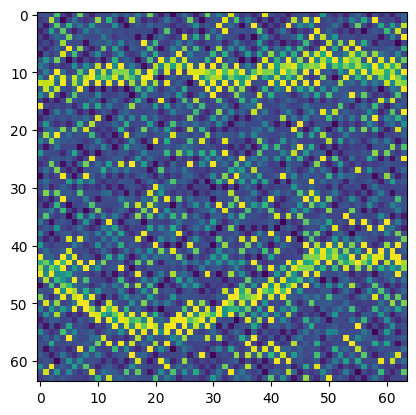

mean 63 :  111.54248046875
clas 63 :  1.0


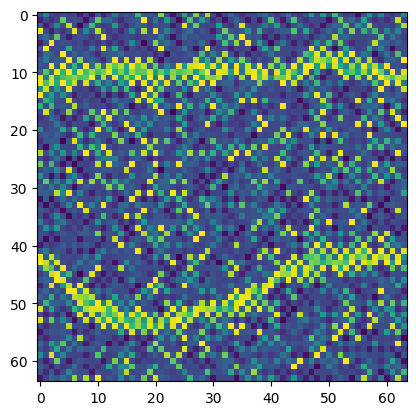

mean 64 :  111.5
clas 64 :  1.0


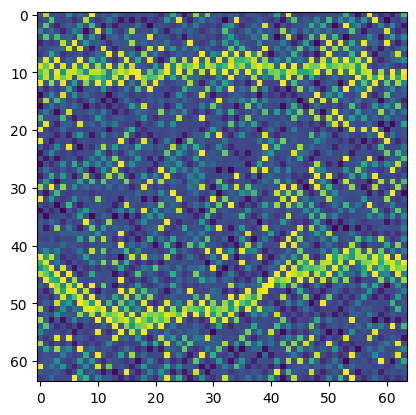

mean 65 :  110.871337890625
clas 65 :  1.0


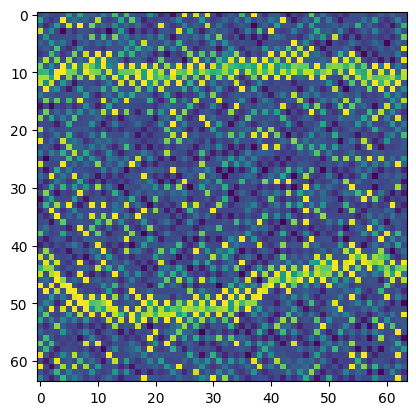

mean 66 :  109.7314453125
clas 66 :  1.0


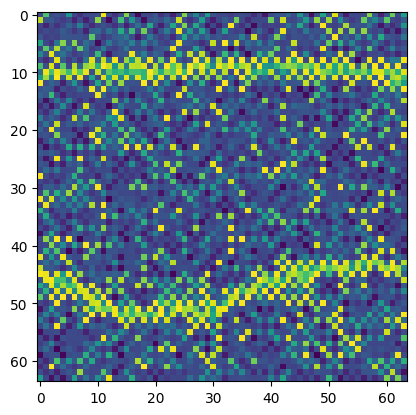

mean 67 :  109.687744140625
clas 67 :  1.0


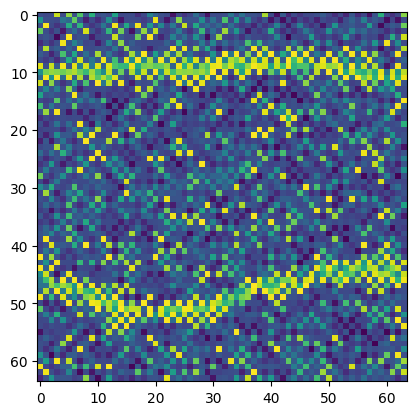

mean 68 :  109.63818359375
clas 68 :  1.0


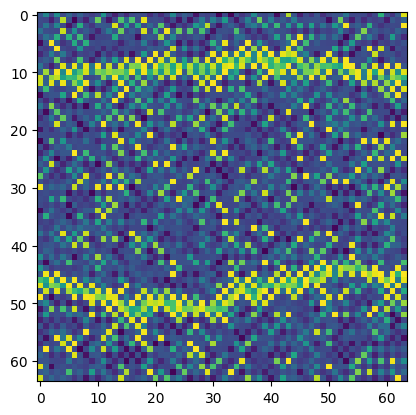

mean 69 :  108.779541015625
clas 69 :  1.0


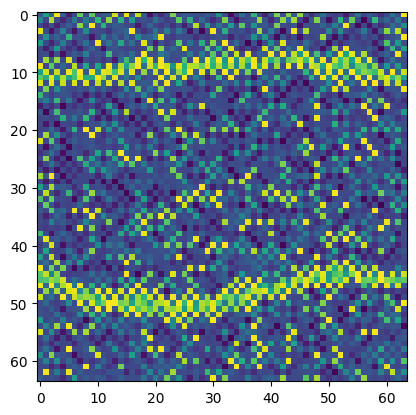

mean 70 :  108.911376953125
clas 70 :  1.0


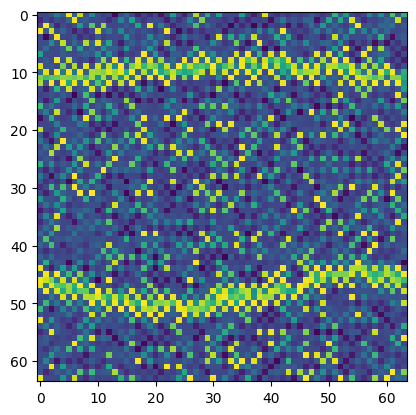

mean 71 :  108.75634765625
clas 71 :  1.0


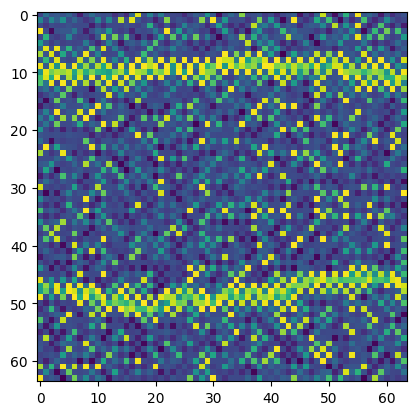

mean 72 :  108.56982421875
clas 72 :  1.0


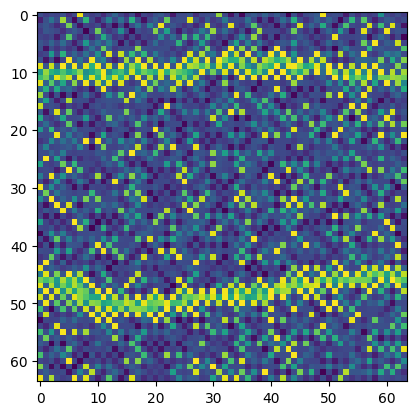

mean 73 :  107.926513671875
clas 73 :  1.0


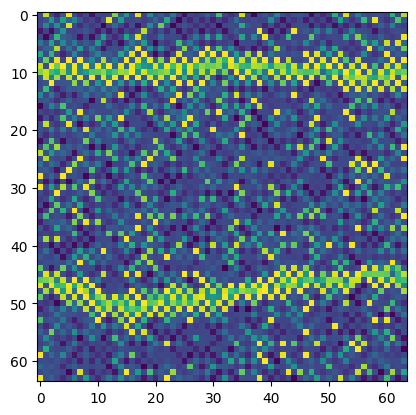

mean 74 :  107.552001953125
clas 74 :  1.0


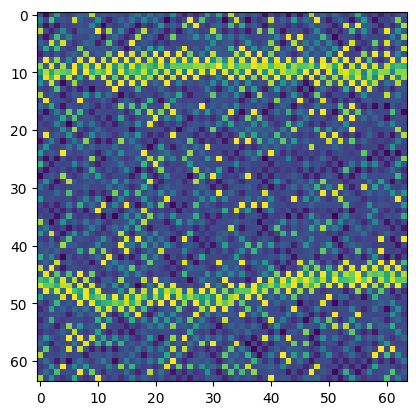

mean 75 :  107.264404296875
clas 75 :  1.0


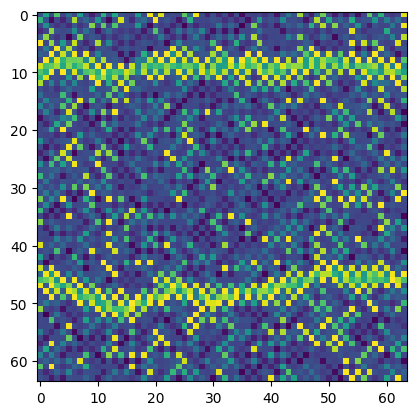

mean 76 :  107.232177734375
clas 76 :  1.0


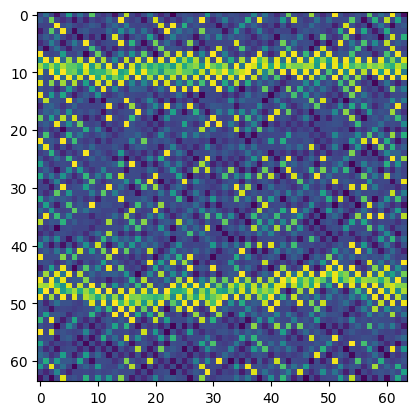

mean 77 :  107.470947265625
clas 77 :  1.0


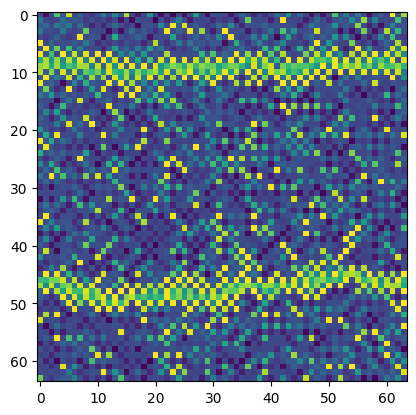

mean 78 :  106.7802734375
clas 78 :  1.0


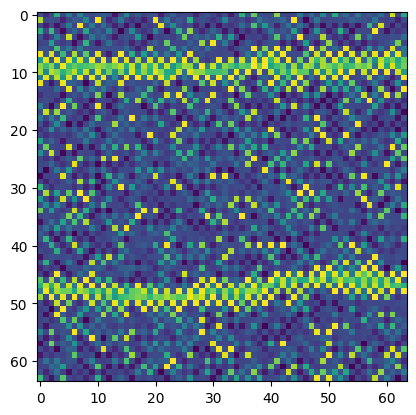

mean 79 :  106.7685546875
clas 79 :  1.0


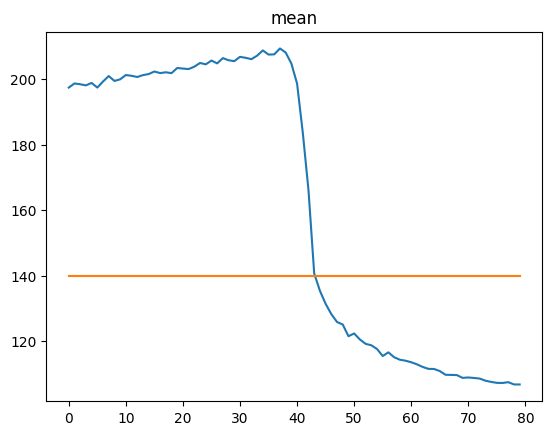

In [ ]:
# ЗАДАЧА КРИТЕРИЯ

# визуализация всего датасета и картинок
crit = 130 # выбор критерия

for i in range(np.shape(mean)[0]):
  if mean[i]>crit:
    clas[i] = 0
  else:
    clas[i] = 1

  print ('i:',i,' clas:',clas)


for i in range(np.shape(mean)[0]):
  plt.imshow(pic_mat[i])
  plt.show()

  print ('mean', i, ': ', mean[i])
  print ('clas', i, ': ', clas[i])

plt.plot(x, mean)
plt.title('mean')

y_crit = np.full (np.shape(mean)[0], crit)
plt.plot(x, y_crit)

# визуализация картинки под номером N_pic
# N_pic = 2
#
# plt.imshow(pic_mat[N_pic])
# plt.show()

In [ ]:
mat = np.array ([])
for i in range (10):
  if i%2==1:
    continue
  mat = np.append(mat, i)

print (mat)

mat2 = np.array ([[1,1,1,1,1],
                  [2,2,2,2,2],
                  [3,3,3,3,3],
                  [4,4,4,4,4]])

mat2 = np.delete(mat2, 3, 0)
print (mat2)

[0. 2. 4. 6. 8.]
[[1 1 1 1 1]
 [2 2 2 2 2]
 [3 3 3 3 3]]


In [ ]:
# объединение массивов numpy
a = np.array([[1, 2], [3, 4]])
b = np.array([[5, 6], [7, 8]])

c1 = np.concatenate((a, b), axis=0)
print ('c1:', c1)

c2 = np.concatenate((a, b), axis=1)
print ('c2:', c2)

c3 = np.concatenate((a, b), axis=None)
print ('c3:', c3)


c1: [[1 2]
 [3 4]
 [5 6]
 [7 8]]
c2: [[1 2 5 6]
 [3 4 7 8]]
c3: [1 2 3 4 5 6 7 8]


In [ ]:
# немного практики с torch-тенозорами. Создание (2 способа), объединие 3 тензоров в один
x1 = torch.tensor ([[1,1,1],[1,1,1],[1,1,1]])
x2 = torch.full((3, 3), 2)
x3 = torch.full((3, 3), 3)

print (x1, x2, x3)

x_res = torch.cat((x1,x2,x3),1)
print (x_res)

x_res.unsqueeze_(1)
print (x_res[1])

tensor([[1, 1, 1],
        [1, 1, 1],
        [1, 1, 1]]) tensor([[2, 2, 2],
        [2, 2, 2],
        [2, 2, 2]]) tensor([[3, 3, 3],
        [3, 3, 3],
        [3, 3, 3]])
tensor([[1, 1, 1, 2, 2, 2, 3, 3, 3],
        [1, 1, 1, 2, 2, 2, 3, 3, 3],
        [1, 1, 1, 2, 2, 2, 3, 3, 3]])
tensor([[1, 1, 1, 2, 2, 2, 3, 3, 3]])


In [ ]:
# ручная свертка и пуллинг

mat = train_dataset_x [5,10,0]
print (mat)

plt.imshow(mat)
plt.show()

mask = np.array ([[1,1,1],
                  [1,1,1],
                  [1,1,1]])

# паддинг=1
mat_padding1 = np.zeros ((66,66))
mat_padding1 [1:65,1:65] = mat
#print (mat_padding1)

# 1-ая светрка 3*3
corv1_mat = np.zeros ((64,64))
for i in range(64):
  for j in range (64):
    m = mat_padding1[i:i+3,j:j+3]
    corv1_mat[i,j] = m.sum()

print (corv1_mat)
plt.imshow(corv1_mat)
plt.show()

# 1-ый пулинг 2*2 с шагом 2
pool1_mat = np.zeros((32,32))
t2=0
for i in range(32):
  t1=0
  for j in range (32):
    m = corv1_mat[t2:t2+2,t1:t1+2]
    pool1_mat[i,j] = m.max()
    t1+=2
  t2+=2

print (pool1_mat)
plt.imshow(pool1_mat)
plt.show()

[[ 88.  89. 153. ...  94. 135.  77.]
 [ 83. 225.  87. ... 197. 116. 197.]
 [ 56.  78. 137. ...  89.  46.  84.]
 ...
 [ 87. 169.  78. ...  70.  94.  39.]
 [ 44.  83.  55. ...  91. 191.  85.]
 [ 94.  93.  78. ...  72.  87.  63.]]


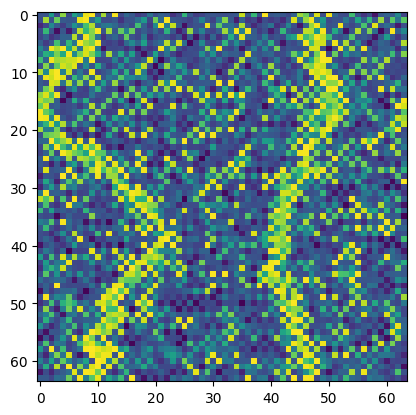

[[ 53.35  79.75  92.07 ...  79.97  89.76  57.75]
 [ 68.09 109.56 126.17 ... 107.03 113.85  72.05]
 [ 77.44 111.87 124.74 ... 118.36 133.98  74.58]
 ...
 [ 65.78  97.79 114.29 ...  88.11  88.11  61.82]
 [ 62.7   85.91 108.24 ...  92.62  87.12  61.49]
 [ 34.54  49.17  55.55 ...  65.23  64.79  46.86]]


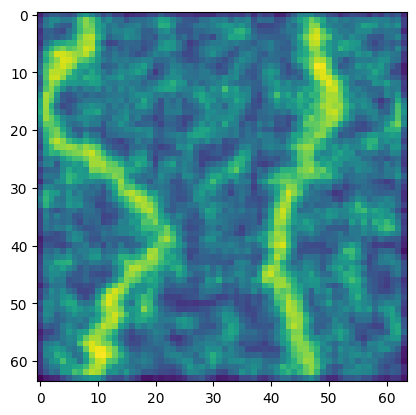

[[109.56 126.17 115.17 ... 123.86 118.91 113.85]
 [111.87 124.74 107.36 ... 138.49 127.49 133.98]
 [107.25 148.06 161.59 ...  90.75 109.34 123.42]
 ...
 [123.53 156.09 147.18 ... 129.8  131.56  94.71]
 [106.7  141.02 171.05 ... 111.54  89.65  88.11]
 [ 85.91 108.24 141.13 ... 109.89  92.62  87.12]]


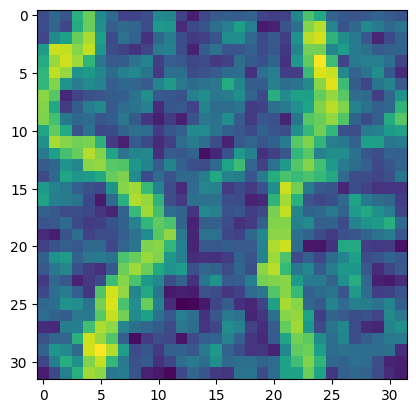

[[ 51.9574  76.4357  89.7215 ...  85.2324  83.2238  54.3653]
 [ 80.0415 122.2947 145.0306 ... 120.0199 118.8099  79.9689]
 [ 95.5537 148.7816 169.0854 ... 121.3872 119.8142  81.5419]
 ...
 [ 84.2039 132.9185 144.958  ... 121.8833 115.3856  74.6812]
 [ 79.3639 129.8935 144.9338 ... 115.2888 102.85    64.2147]
 [ 48.6057  82.9455  97.5139 ...  72.2007  63.6823  39.325 ]]


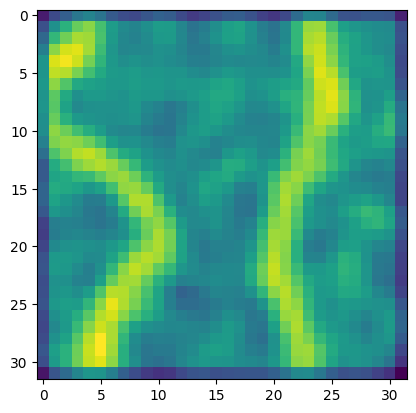

[[122.2947 166.8832 175.5468 130.8615 121.6534 131.0551 115.0952 121.3751
  135.9314 123.662  117.1401 179.2252 180.5562 132.8701 122.8029 118.8099]
 [176.2365 197.472  181.9961 129.8451 119.0156 129.349  115.8696 123.6499
  134.7456 123.4926 122.4641 186.8119 191.9907 146.6399 126.9653 119.8142]
 [195.9958 201.8885 170.1744 129.833  130.922  126.9774 125.2713 122.8997
  128.2116 121.6655 124.1218 177.7369 196.7581 157.8203 133.6082 124.7994]
 [177.2045 159.9257 134.431  127.9575 131.6238 128.8166 128.8166 139.6219
  139.6824 126.8564 144.111  166.8953 198.5973 176.3938 125.6948 132.1441]
 [166.6049 144.2804 124.8478 124.0008 127.655  112.8809 123.783  137.2745
  134.2979 117.9024 136.73   171.2634 196.2862 175.5226 134.2858 150.2336]
 [176.8294 178.3419 168.3352 132.4829 123.8193 111.3684 127.3283 131.527
  120.5281 121.4235 134.7456 176.5632 181.7299 144.6313 142.7679 151.3952]
 [159.0182 185.7108 189.9216 180.3505 150.5724 123.299  122.3068 125.5133
  141.7273 132.0473 155.1099 180.

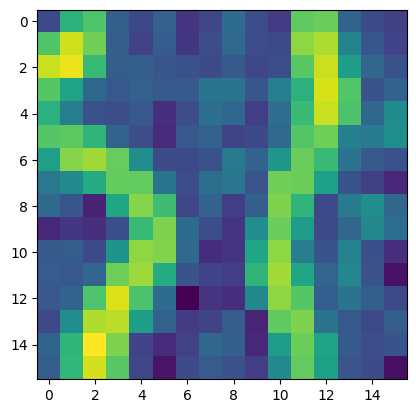

[[ 72.917504 112.247223 108.086517  94.481035  83.795767  80.524169
   81.003329  82.133348  83.914226  83.317938  93.807549 107.600702
  111.99034   99.200761  84.469253  53.723153]
 [116.684777 174.73368  163.295066 141.883269 126.446331 122.672946
  122.269653 123.535434 124.919674 124.457817 140.395211 162.44855
  170.545023 152.901287 130.254322  82.147989]
 [121.95953  175.485695 157.687563 138.137835 126.9774   125.032809
  125.53992  127.464546 127.690816 128.18861  142.357105 166.043581
  175.960862 159.991524 136.8268    83.93286 ]
 [115.048978 162.28883  144.907301 132.158983 125.47337  125.042126
  126.097609 129.784479 128.525353 129.09369  141.601097 166.375
  177.900129 164.446381 144.155286  88.084249]
 [110.350548 157.388088 142.406352 131.466863 123.266572 122.770109
  125.555892 130.114567 128.602551 129.390503 142.613988 165.761409
  174.66713  162.350056 146.637601  92.017354]
 [111.186416 164.327922 157.109909 145.418405 130.507212 123.531441
  122.680932 128.0714

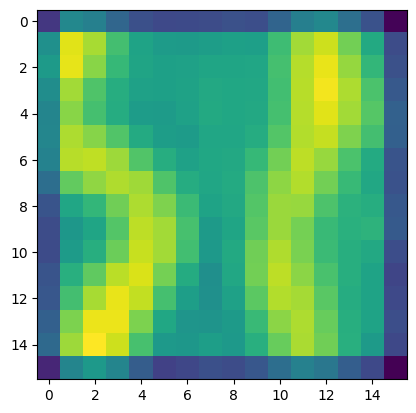

[[174.73368  163.295066 126.446331 123.535434 124.919674 162.44855
  170.545023 130.254322]
 [175.485695 157.687563 126.9774   129.784479 129.09369  166.375
  177.900129 144.155286]
 [164.327922 157.109909 130.507212 130.114567 131.39632  165.761409
  174.66713  146.637601]
 [166.367014 168.080011 161.981369 131.697126 144.313675 167.427821
  160.630404 130.5711  ]
 [128.227209 152.693651 167.658084 143.238227 147.734345 161.150825
  144.436127 135.033943]
 [132.875061 167.031183 172.899562 141.629048 152.777504 167.703338
  143.403271 129.515617]
 [154.797962 176.445346 168.255703 124.131722 147.859459 165.626978
  150.552072 126.603389]
 [161.510195 180.237365 143.218262 124.079813 132.988196 163.855417
  152.556558 122.229723]]


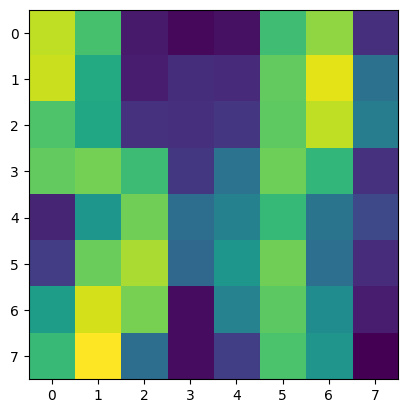

In [ ]:
# ручная свертка и пуллинг

def convolution (mat, mask, padding): # свертка 3*3
  shape=np.shape(mat)

  # паддинг
  padd1 = padding
  padd2 = 2*padding
  mat_padding = np.zeros ((shape[0]+padd2,shape[1]+padd2))
  shape_pad = np.shape(mat_padding)

  mat_padding [padd1:shape_pad[0]-padd1,padd1:shape_pad[1]-padd1] = mat

  corv_mat = np.zeros ((shape[0]-2+padd2,shape[1]-2+padd2))
  shape_corv = np.shape(corv_mat)
  for i in range(shape_corv[0]):
    for j in range (shape_corv[1]):
      m = mat_padding[i:i+3,j:j+3]
      m = m*mask
      corv_mat[i,j] = m.sum()
  return corv_mat

def maxpool (mat):  # 1-ый пулинг 2*2 с шагом 2
  shape=np.shape(mat)
  pool_mat = np.zeros((int(shape[0]/2),int(shape[0]/2)))
  t2=0
  for i in range(int(shape[0]/2)):
    t1=0
    for j in range (int(shape[1]/2)):
      m = mat[t2:t2+2,t1:t1+2]
      pool_mat [i,j] = m.max()
      t1+=2
    t2+=2
  return pool_mat

mat = train_dataset_x [5,10,0]
print (mat)

plt.imshow(mat)
plt.show()

mask = np.array ([[0.11,0.11,0.11],
                  [0.11,0.11,0.11],
                  [0.11,0.11,0.11]])

mat = convolution(mat, mask, 1)
print (mat)
plt.imshow(mat)
plt.show()

mat = maxpool(mat)
print (mat)
plt.imshow(mat)
plt.show()

mat = convolution(mat, mask, 1)
print (mat)
plt.imshow(mat)
plt.show()

mat = maxpool(mat)
print (mat)
plt.imshow(mat)
plt.show()

mat = convolution(mat, mask, 1)
print (mat)
plt.imshow(mat)
plt.show()

mat = maxpool(mat)
print (mat)
plt.imshow(mat)
plt.show()